In [7]:
# ================================================================
# OCR CELL 1 — Imports & Load EasyOCR
# ================================================================
import easyocr
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load EasyOCR — first time will download the model (~100MB)
# en = English, this might take 1-2 minutes first time only
reader = easyocr.Reader(['en'])

print('EasyOCR is ready!')

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


EasyOCR is ready!


In [8]:
# ================================================================
# OCR CELL 2 — Extract Text from Image Function
# ================================================================
def extract_text(image_path):
    # Read the image
    results = reader.readtext(image_path)
    
    # Join all detected text together into one string
    full_text = ' '.join([text for (_, text, confidence) in results if confidence > 0.3])
    
    return full_text

print('extract_text() is ready!')

extract_text() is ready!


In [9]:
# ================================================================
# OCR CELL 3 — Show Image + Extracted Text (fixed)
# ================================================================
def show_image_with_boxes(image_path):
    from PIL import Image, ImageDraw
    
    image = Image.open(image_path).convert('RGB')
    draw  = ImageDraw.Draw(image)
    results = reader.readtext(image_path)
    
    for (bbox, text, confidence) in results:
        if confidence > 0.3:
            # Draw green box around each detected text
            x0 = int(bbox[0][0])
            y0 = int(bbox[0][1])
            x1 = int(bbox[2][0])
            y1 = int(bbox[2][1])
            draw.rectangle([x0, y0, x1, y1], outline='green', width=2)
    
    plt.figure(figsize=(14, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title('Detected Text in Image', fontsize=14, fontweight='bold')
    plt.show()

print('show_image_with_boxes() is ready!')

show_image_with_boxes() is ready!


In [10]:
# ================================================================
# OCR CELL 4 — Full Pipeline Function
# ================================================================
import pickle
import re

# Load the saved model and vectorizer directly
vectorizer = pickle.load(open(r'C:\Users\wtpir\Documents\AI fake news detector\news\AI\Text Models\Text Model\tfidf_vectorizer.pkl', 'rb'))
best_model = pickle.load(open(r'C:\Users\wtpir\Documents\AI fake news detector\news\AI\Text Models\Text Model\best_fake_news_model.pkl', 'rb'))

def predict_news(text, confidence_threshold=0.40):
    text = re.sub(r'^[A-Z\s,\.]+\(Reuters\)\s*[-\u2013]\s*', '', str(text))
    text_tfidf = vectorizer.transform([text])
    if text_tfidf.nnz == 0:
        return 'Uncertain (No known words) ❓'
    prob = best_model.predict_proba(text_tfidf)[0]
    pred = best_model.predict(text_tfidf)[0]
    confidence = prob[pred]
    if confidence < confidence_threshold:
        return f'Uncertain (Confidence: {confidence:.2f}) ❓'
    return 'Real 🟢' if pred == 1 else 'Fake 🔴'

def analyze_news_image(image_path):
    print(f'Analyzing: {image_path}')
    print('=' * 50)
    
    extracted_text = extract_text(image_path)
    
    if not extracted_text.strip():
        print('No text detected in this image.')
        return
    
    print(f'Extracted Text:\n{extracted_text}')
    print('=' * 50)
    
    show_image_with_boxes(image_path)
    
    prediction = predict_news(extracted_text)
    
    print(f'Prediction: {prediction}')
    print('=' * 50)
    
    return prediction

print('analyze_news_image() is ready!')

analyze_news_image() is ready!


Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 115259.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
The Road That Has No End Mariah Lightenings Last InterviewAs the curtains close on a life and career; the 54 year old rockstar gives her final statements to her beloved fans and staunch critics. She's hardly recognizable: The once powerfully strong build that performed olympic level dives off arena stages is now an amalgamation of flimsy bones on a hospital bed. Her iconic glittery unitard has been replaced by a gown. The only music in Mariah Lightenings presence these days is the beeping and groaning of her dialysis machine Shes bee _


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


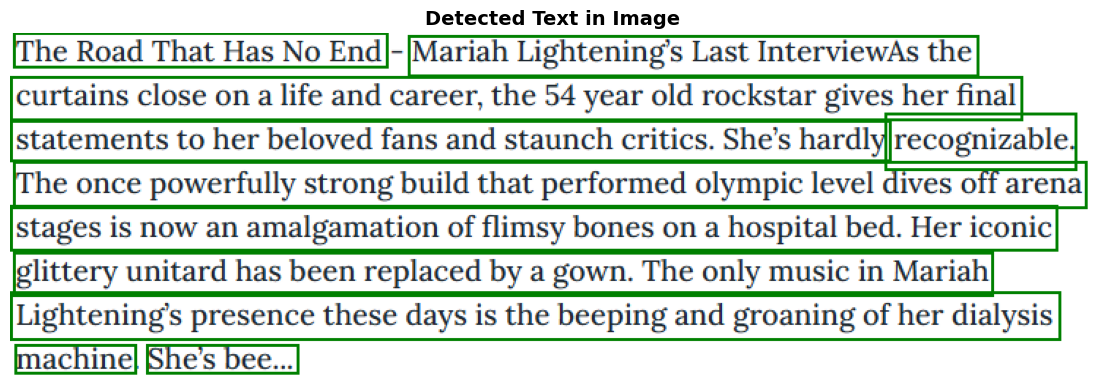

Prediction: Fake 🔴


In [11]:
# ================================================================
# OCR CELL 5 — Test with your image
# Change the path to your screenshot
# ================================================================

# ✅ Change this path to your screenshot
image_path = r"C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 115259.png"

result = analyze_news_image(image_path)

Found 8 images


📸 Image: Screenshot 2026-03-28 122043.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122043.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
BREAKING: Hillary Clinton ARRESTED by FBl agentsll Sources confirm Obama involved in MASSIVE COVER-UP Share before they DELETE THISU


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


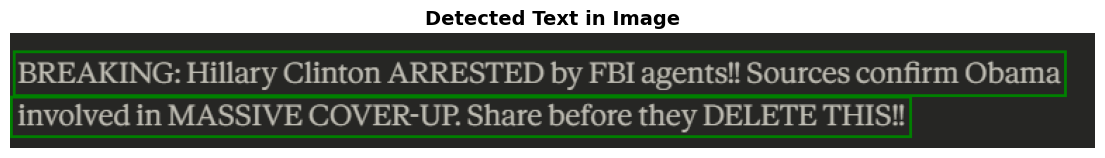

Prediction: Fake 🔴


📸 Image: Screenshot 2026-03-28 122047.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122047.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
SHOCK REPORT: Bill Gates admits vaccines contain microchips to track your locationll Government hiding the TRUTH from millions WAKE UP PEOPLEI


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


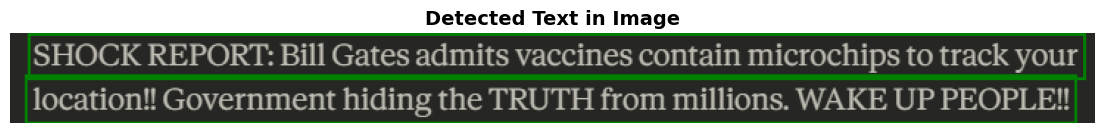

Prediction: Fake 🔴


📸 Image: Screenshot 2026-03-28 122051.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122051.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
BOMBSHELL: George Soros personally funding ANTIFA terrorists to destroy Americall Patriots must RISE UP before it's too late. SHARE EVERYWHEREI


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


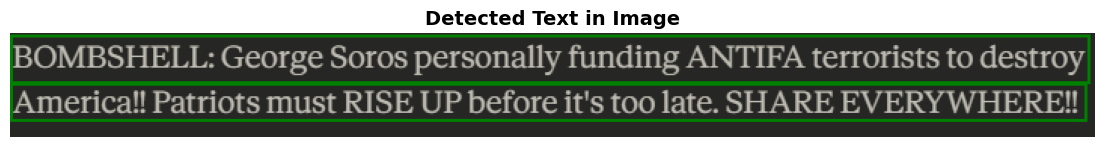

Prediction: Fake 🔴


📸 Image: Screenshot 2026-03-28 122058.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122058.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
CONFIRMED: SG towers being used to spread COVID-19 on purposell Deep state behind the whole plan to DEPOPULATE the earthll


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


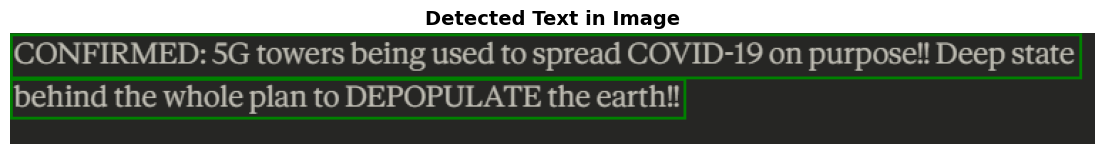

Prediction: Fake 🔴


📸 Image: Screenshot 2026-03-28 122104.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122104.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday; citing continued progress toward its 2 percent inflation target:


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


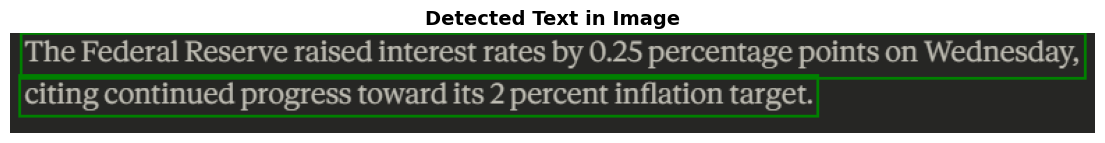

Prediction: Real 🟢


📸 Image: Screenshot 2026-03-28 122108.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122108.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
President Trump signed an executive order directing federal agencies to reduce regulations on small businesses; calling the move a boost to economic growth:


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


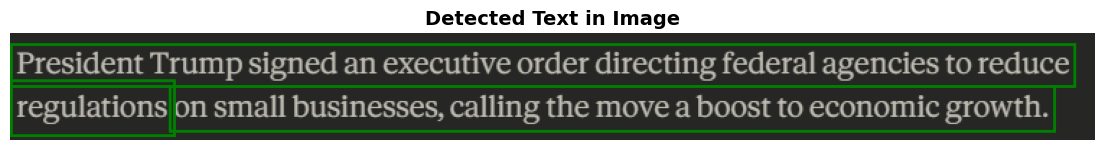

Prediction: Fake 🔴


📸 Image: Screenshot 2026-03-28 122112.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122112.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
The Senate voted to confirm the president's nominee to the federal appeals court; with all Democrats voting against the confirmation:


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


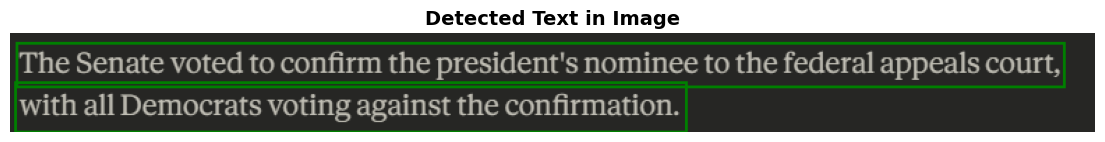

Prediction: Real 🟢


📸 Image: Screenshot 2026-03-28 122123.png
Analyzing: C:\Users\wtpir\Documents\Datasets\images\Screenshot 2026-03-28 122123.png


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
Congress approved a bill to fund the government through February,avoidinga shutdown after weeks of negotiations between Republican and Democratic leaders:


c:\Users\wtpir\Documents\AI fake news detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


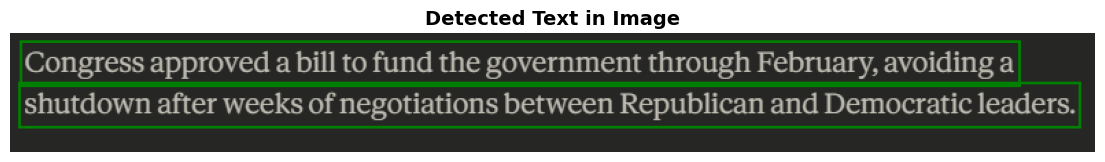

Prediction: Real 🟢



In [14]:
# ================================================================
# OCR CELL 6 — Test multiple images at once
# ================================================================
import os

# ✅ Updated to correct path
folder_path = r"C:\Users\wtpir\Documents\Datasets\images"

images = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

print(f'Found {len(images)} images\n')

for image_file in images:
    full_path = os.path.join(folder_path, image_file)
    print(f'\n📸 Image: {image_file}')
    analyze_news_image(full_path)
    print()